In [6]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np


# Define the path to the src directory manually
src_path = os.path.abspath('../src')
sys.path.insert(0, src_path)

plt.style.use('tableau-colorblind10')

# Load constants
from constUnitConvert import ConstantsUnitConversion
from constGlobal import ConstantsGlobal

CONVERT = ConstantsUnitConversion()
GLOBAL = ConstantsGlobal()

# Step 1: Load tidal data

/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#t

Mooring Distance (m): 50.0
Latitude (radians): 0.9891915335065662
Longitude (radians): -2.3340724419233165
Station Name: Summit Island, west of
Nearest City: Kake
Cable Length (m): 41236.37


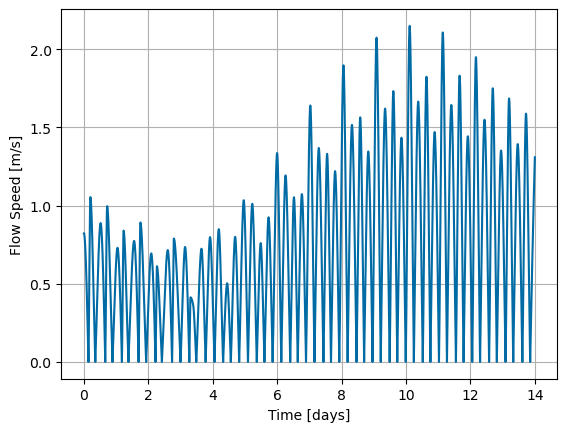

In [ ]:
# import the TidalData class from the module_tidal module
from module_tidal import TidalData

# define the parameters required to initialize the TidalData class
# station identifier, start date, range in hours, and time step in seconds
station = "PCT3716"  # Site 2
startdate = 20200201  # yyyyMMdd
rangeHr = 2 * 7 * 24  # Two weeks
timestep = 5.0  # Timestep in seconds

# create an instance of the TidalData class using the parameters defined
tidal_data = TidalData(station, startdate, rangeHr, timestep)

# specify the path to the city coordinate file  
# use the load_tidal_data method to load the tidal data
CityCoordinateFile = "../data/AlaskaCityLatLong.txt"
flow_speeds, times, dmoor_m, lat_rad, lon_rad, station_name, nearest_city, cable_length = tidal_data.load_tidal_data(CityCoordinateFile)

# Display the loaded data
print("Mooring Distance (m):", dmoor_m)
print("Latitude (radians):", lat_rad)
print("Longitude (radians):", lon_rad)
print("Station Name:", station_name)
print("Nearest City:", nearest_city)
print("Cable Length (m):", cable_length)


# Plot the flow speeds over time
plt.figure()
plt.plot(times / (24 * 3600), flow_speeds)
plt.xlabel('Time [days]')
plt.ylabel('Flow Speed [m/s]') 
plt.grid()
plt.show()

# Step 2: Load rotor performance map

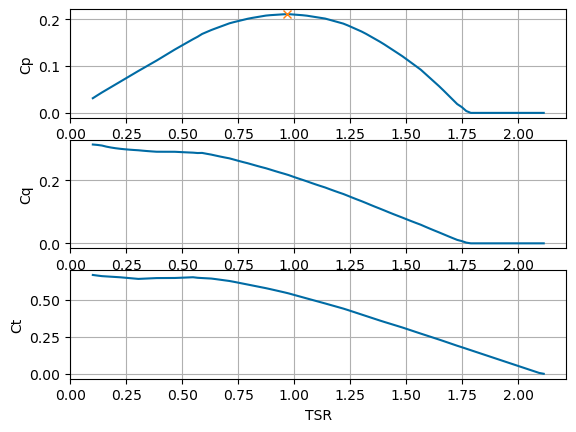

In [ ]:
# import the RotorData class from the module_rotor module
from module_rotor import RotorData

RotorPerformanceFile = "../data/Sitkana_rotor_data_blade_1.txt"
rotor_data = RotorData(RotorPerformanceFile)

TSR_val = np.linspace(0.1,rotor_data.TSRmax,100)

plt.figure()
plt.subplot(3,1,1)
plt.plot(TSR_val,rotor_data.get_cp(TSR_val))
plt.plot(rotor_data.TSROpt,rotor_data.CpOpt,'x')
plt.ylabel('Cp') 
plt.grid() 

plt.subplot(3,1,2)
plt.plot(TSR_val,rotor_data.get_cq(TSR_val))
plt.ylabel('Cq') 
plt.grid() 

plt.subplot(3,1,3)
plt.plot(TSR_val,rotor_data.get_ct(TSR_val))
plt.xlabel('TSR')
plt.ylabel('Ct') 
plt.grid()